```
## GraphSAGE_Data002_NodeManufacturing_v1.ipynb

Inputs
------
Superfunds:
- /content/DATA001_superfund_feature_matrix_v1.csv
- /content/DATA001_superfund_node_id_map_v1.csv
Counties:
- /content/DATA002_county_feature_matrix_v1.csv
- /content/DATA002_county_node_id_map_v1.csv

Functions:
- creates edge_indices, instantiates graph object
- prepares Heterograph class, defines model
- trains, produces data, simple visualization of results

Not yet refactored and included:
- hyperparameter training via Optuna
```

```
# ───────────────────────────────────────────────────────────────────────
# CODE CELL 1.0: ENVIRONMENT AND RUNTIME CONTROL
# ───────────────────────────────────────────────────────────────────────

Note: This notebook is being developed with Python in a Colab notebook
using an L4 or A100 hardware accelerator. There are runtime-specific   
dependencies that must be aligned. Cell 1 should be run prior to   
starting work in each new runtime. After Cell 1 completes, the runtime  
must be restarted. Cell 1 may then be commented out to avoid   
reinstalling the dependencies after subsequent runtime restarts.
```

In [ ]:
# !pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse torch-geometric
# !pip install torch==2.0.0+cu118 torchvision==0.15.1+cu118 torchaudio==2.0.1+cu118 -f https://download.pytorch.org/whl/torch_stable.html
# !pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
# !pip install numpy==1.24.4
# !pip install Optuna

```
# ───────────────────────────────────────────────────────────────────────
# CODE CELL 2.0: IMPORT STATEMENTS
# ───────────────────────────────────────────────────────────────────────
```

In [ ]:
# Torch and torch utilities are for construction of HeteroGRAPH object
# ───────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch_geometric
from torch_geometric.data import HeteroData
from torch.optim import Adam
from torch_geometric.nn import SAGEConv, HeteroConv
import numpy as np


# Sklearn encoder, training and evaluation tools
# ───────────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import optuna

# Data handling libraries
# ───────────────────────────────────────────────────────────────────────
from shapely.geometry import Point # For reading geometry in super_gdf
import geopandas as gpd            # For loading super_gdf
import pandas as pd

# Utilities
# ───────────────────────────────────────────────────────────────────────
from google.colab import files
import random
import inspect
import math
import time
import re

# Utilities
# ───────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import tabulate
from tabulate import tabulate
import collections
from collections import Counter

# Set random state for everything, everywhere, all at once.
# ───────────────────────────────────────────────────────────────────────
def jenny_setter(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

jenny = 8675309
jenny_setter(seed=jenny)

# Check runtime dependency control. Confirm correct PyTorch, CUDA, numpy.
# ───────────────────────────────────────────────────────────────────────
rows = [
        ["Torch", "Torch 2.0.0+cu118", torch.__version__],
        ["CUDA_version", "11.8", torch.version.cuda],
        ["NumPy", "NumPy 1.24.4", np.__version__]
       ]
print(tabulate(rows, headers=["Library", "Expected Version", "Current Version"], tablefmt="grid"))

+--------------+--------------------+-------------------+
| Library      | Expected Version   | Current Version   |
+==============+====================+===================+
| Torch        | Torch 2.0.0+cu118  | 2.0.0+cu118       |
+--------------+--------------------+-------------------+
| CUDA_version | 11.8               | 11.8              |
+--------------+--------------------+-------------------+
| NumPy        | NumPy 1.24.4       | 1.24.4            |
+--------------+--------------------+-------------------+


In [ ]:
superfund_feature_matrix = pd.read_csv('/content/DATA001_superfund_feature_matrix_v1.csv', low_memory=False)
superfund_node_id_map = pd.read_csv('/content/DATA001_superfund_node_id_map_v1.csv', low_memory=False)
county_feature_matrix = pd.read_csv('/content/DATA002_county_feature_matrix_v1.csv', low_memory=False)
county_node_id_map = pd.read_csv('/content/DATA002_county_node_id_map_v1.csv', low_memory=False)

# >>> Enforce formats (strings, padded to n digits) for id columns <<<
# >>> ------------------------------------------------------------ <<<
superfund_node_id_map['site_id'] = superfund_node_id_map['site_id'].astype(str).str.zfill(7)
superfund_node_id_map['fips'] = superfund_node_id_map['fips'].astype(str).str.zfill(5)
county_node_id_map['fips'] = county_node_id_map['fips'].astype(str).str.zfill(5)

# >>> Cast everything in feature matrices to float32; mixed dtypes <<<
# >>> trigger implicit casting when used in PyTorch Geo operations <<<
# >>> ------------------------------------------------------------ <<<
superfund_feature_matrix = superfund_feature_matrix.astype(np.float32)
county_feature_matrix = county_feature_matrix.astype(np.float32)

```
# ───────────────────────────────────────────────────────────────────────
# CODE CELL 3.0: DATA - IMPORT VERIFICATION
# ───────────────────────────────────────────────────────────────────────
```


In [ ]:
display(superfund_feature_matrix.info())
print('-------------------------------')
print('__ HEAD __')
display(superfund_feature_matrix.head())
print('-------------------------------')
print('__ SHAPE __')
display(superfund_feature_matrix.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Columns: 739 entries, lat to npl_proposed
dtypes: float32(739)
memory usage: 4.5 MB


None

-------------------------------
__ HEAD __


,lat,lon,fed_facility,native_land,hazard_rank_score,final_list_days,proposed_days,proposal_gulf,is_finalized,is_deleted,...,99-35-4,99-65-0,99-87-6,99-99-0,993-13-5,UNASSIGNED,cas_sum,npl_current,npl_deleted,npl_proposed
0,41.940559,-71.966942,0.0,0.0,33.709999,12733.0,13340.0,607.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,1.0,0.0,0.0
1,41.481110,-72.681389,0.0,0.0,33.939999,12873.0,13340.0,467.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,43.0,1.0,0.0,0.0
2,41.708332,-71.829170,0.0,0.0,41.060001,13678.0,14085.0,407.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,1.0,0.0
3,41.619598,-72.877998,0.0,0.0,44.930000,15091.0,15343.0,252.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,94.0,1.0,0.0,0.0
4,41.669449,-71.964165,0.0,0.0,36.720001,15091.0,15343.0,252.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,66.0,1.0,0.0,0.0


-------------------------------
__ SHAPE __


(1606, 739)

In [ ]:
display(superfund_node_id_map.info())
print('-------------------------------')
print('__ HEAD __')
display(superfund_node_id_map.head())
print('-------------------------------')
print('__ SHAPE __')
display(superfund_node_id_map.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   row_index  1606 non-null   int64 
 1   site_id    1606 non-null   object
 2   fips       1606 non-null   object
dtypes: int64(1), object(2)
memory usage: 37.8+ KB


None

-------------------------------
__ HEAD __


,row_index,site_id,fips
0,0,0100041,09150
1,1,0100108,09130
2,2,0100121,09150
3,3,0100124,09110
4,4,0100125,09150


-------------------------------
__ SHAPE __


(1606, 3)

In [ ]:
display(county_feature_matrix.info())
print('-------------------------------')
print('__ HEAD/TAIL __')
display(county_feature_matrix.head())
display(county_feature_matrix.tail())
print('-------------------------------')
print('__ SHAPE __')
display(county_feature_matrix.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cancer_rate       2930 non-null   float32
 1   avg_annual_count  2930 non-null   float32
 2   five_year_trend   2930 non-null   float32
 3   rural_rural       2930 non-null   float32
 4   rural_urban       2930 non-null   float32
 5   trend_            2930 non-null   float32
 6   trend_falling     2930 non-null   float32
 7   trend_rising      2930 non-null   float32
 8   trend_stable      2930 non-null   float32
dtypes: float32(9)
memory usage: 103.1 KB


None

-------------------------------
__ HEAD/TAIL __


,cancer_rate,avg_annual_count,five_year_trend,rural_rural,rural_urban,trend_,trend_falling,trend_rising,trend_stable
0,693.500000,37.0,2.2,1.0,0.0,0.0,0.0,0.0,1.0
1,679.500000,436.0,-0.3,1.0,0.0,0.0,0.0,0.0,1.0
2,655.000000,55.0,1.7,1.0,0.0,0.0,0.0,0.0,1.0
3,653.099976,21.0,0.7,1.0,0.0,0.0,0.0,0.0,1.0
4,634.500000,28.0,1.3,1.0,0.0,0.0,0.0,0.0,1.0


,cancer_rate,avg_annual_count,five_year_trend,rural_rural,rural_urban,trend_,trend_falling,trend_rising,trend_stable
2925,219.100006,7.0,-999.0,1.0,0.0,1.0,0.0,0.0,0.0
2926,219.000000,6.0,-2.1,0.0,1.0,0.0,0.0,0.0,1.0
2927,208.000000,10.0,-2.5,1.0,0.0,0.0,0.0,0.0,1.0
2928,207.399994,4.0,-1.6,1.0,0.0,0.0,0.0,0.0,1.0
2929,182.300003,3.0,-5.2,1.0,0.0,0.0,0.0,0.0,1.0


-------------------------------
__ SHAPE __


(2930, 9)

In [ ]:
display(county_node_id_map.info())
print('-------------------------------')
print('__ HEAD/TAIL __')
display(county_node_id_map.head())
display(county_node_id_map.tail())
print('-------------------------------')
print('__ SHAPE __')
display(county_node_id_map.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   row_index  2930 non-null   int64 
 1   fips       2930 non-null   object
dtypes: int64(1), object(1)
memory usage: 45.9+ KB


None

-------------------------------
__ HEAD/TAIL __


,row_index,fips
0,0,27155
1,1,48373
2,2,51640
3,3,31077
4,4,46041


,row_index,fips
2925,2925,02013
2926,2926,38065
2927,2927,48243
2928,2928,08079
2929,2929,08053


-------------------------------
__ SHAPE __


(2930, 2)

In [ ]:
# >>> Check that fips match between superfund and county id_maps.          <<<
# >>> -------------------------------------------------------------------- <<<
valid_fips = set(county_node_id_map['fips'])
superfund_fips = set(superfund_node_id_map['fips'])
print("Edges possible:", len(superfund_fips & valid_fips), "/", len(superfund_fips))

# >>> Check that fips are all digit-only and appropriately 5-padded.       <<<
# >>> -------------------------------------------------------------------- <<<
valid_fips = county_node_id_map['fips'].apply(lambda x: isinstance(x, str) and len(x) == 5 and x.isdigit())
print("Valid FIPS count:", valid_fips.sum(), "/", len(county_node_id_map))

Edges possible: 677 / 738
Valid FIPS count: 2930 / 2930


```
# ───────────────────────────────────────────────────────────────────────
# CODE CELL 4.0: EDGE CONSTRUCTION
# ───────────────────────────────────────────────────────────────────────
```

In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 4.1: EDGE CONSTRUCTION / INSTANTIATE DATA OBJECT             <<<
# ────────────────────────────────────────────────────────────────────────── <<<

# >>> Create base edge index <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
edge_df = superfund_node_id_map.merge(county_node_id_map, on='fips',
                                      suffixes=('_superfund', '_county')).copy(deep=True)
edge_array = np.stack([
    edge_df['row_index_superfund'].values,
    edge_df['row_index_county'].values
], axis=0)
edge_index = torch.from_numpy(edge_array).long()
# >>> ────────────────────────────────────────────────────────────────────── <<<

# >>> VERIFICATION OF SHAPE                                                  <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
print("Edge index shape:", edge_index.shape)
# >>> ────────────────────────────────────────────────────────────────────── <<<

# >>> TURN FEATURE MATRICES TO TENSORS                                       <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
superfund_x = torch.tensor(superfund_feature_matrix.values, dtype=torch.float32)
county_x = torch.tensor(county_feature_matrix.values, dtype=torch.float32)

# >>> INSTANTIATE HETERODATA OBJECT AND ADD FEATURES                         <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
data = HeteroData()
data['superfund'].x = superfund_x

# >>> split cancer_rate (is the target) from the features. <<<
county_feats = county_feature_matrix.drop(columns=['cancer_rate']).copy()
county_x = torch.tensor(county_feats.values, dtype=torch.float32)
data['county'].x = county_x
data['superfund','located_in','county'].edge_index=edge_index
data['county', 'has_site', 'superfund'].edge_index = edge_index.flip(0)

# >>> VALIDATION CODE                                                        <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
print('__ Data Object __')
print(data)
print('-------------------------------')
print('__ data["superfund"].x.shape __')
print(data['superfund'].x.shape)
print('-------------------------------')
print('__ data["county"].x.shape __')
print(data['county'].x.shape)
print('-------------------------------')
print('__ data["superfund", "located_in", "county"].edge_index.shape __')
print(data['superfund', 'located_in', 'county'].edge_index.shape)
print('-------------------------------')
print()
print('__ double check that indices have not been shuffled __')
assert np.array_equal(county_node_id_map['row_index'].values, county_feature_matrix.index.values), \
    "Mismatch: row_index and feature matrix index are not aligned."
print('-------------------------------')
print()
print('__ double check that IDs still match __')
assert np.array_equal(county_node_id_map['row_index'].values, county_feature_matrix.index.values), \
    "ERROR: Misaligned county_node_id_map and county_feature_matrix."

assert np.array_equal(superfund_node_id_map['row_index'].values, superfund_feature_matrix.index.values), \
    "ERROR: Misaligned superfund_node_id_map and superfund_feature_matrix."
print('-------------------------------')

Edge index shape: torch.Size([2, 1505])
__ Data Object __
HeteroData(
  superfund={ x=[1606, 739] },
  county={ x=[2930, 8] },
  (superfund, located_in, county)={ edge_index=[2, 1505] },
  (county, has_site, superfund)={ edge_index=[2, 1505] }
)
-------------------------------
__ data["superfund"].x.shape __
torch.Size([1606, 739])
-------------------------------
__ data["county"].x.shape __
torch.Size([2930, 8])
-------------------------------
__ data["superfund", "located_in", "county"].edge_index.shape __
torch.Size([2, 1505])
-------------------------------

__ double check that indices have not been shuffled __
-------------------------------

__ double check that IDs still match __
-------------------------------


```
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 5.0: ASSIGN LABELS, CREATE MASKS                             <<<
# ────────────────────────────────────────────────────────────────────────── <<<
```

Mean:   454.41
Median: 459.90
Std:    58.15


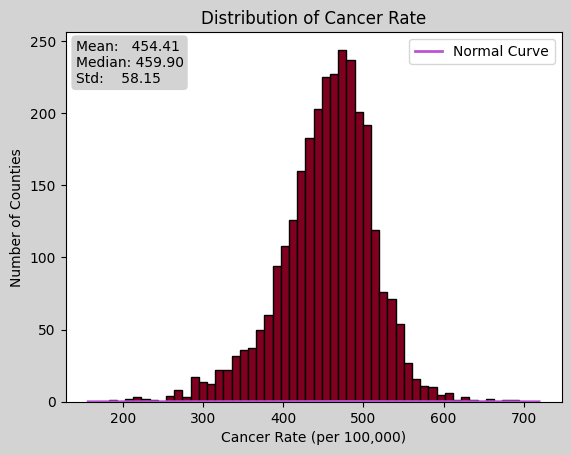


Scaling decision: Do not scale first attempt. Mean is .988 of median.
─────────────────────────────────────────────────────────────────────


In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 5.0: JUSTIFY SCALING DECISION                                <<<
# ────────────────────────────────────────────────────────────────────────── <<<
from scipy.stats import norm

dist_check = county_feature_matrix['cancer_rate']
mean = dist_check.mean()
median = dist_check.median()
std = dist_check.std()

print(f"Mean:   {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Std:    {std:.2f}")

fig, ax = plt.subplots(facecolor='lightgray')
ax.hist(dist_check, bins=50, color='#800020', edgecolor='black')


# Normal distribution curve
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 500)
p = norm.pdf(x, mean, std)
ax.plot(x, p * len(data) * (xmax - xmin) / 50, color='mediumorchid', linewidth=2, label='Normal Curve')

# Add legend
ax.legend()

# Annotate stats in top-left corner
stats_text = f"Mean:   {mean:.2f}\nMedian: {median:.2f}\nStd:    {std:.2f}"
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor='lightgray', edgecolor='none', boxstyle='round'))

# Label and title
ax.set_title('Distribution of Cancer Rate')
ax.set_xlabel('Cancer Rate (per 100,000)')
ax.set_ylabel('Number of Counties')
plt.show()
print()
print('Scaling decision: Do not scale first attempt. Mean is .988 of median.')
print('─────────────────────────────────────────────────────────────────────')

In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 5.2.1: ASSIGN COUNTY NODE TARGET LABELS                      <<<
# ────────────────────────────────────────────────────────────────────────── <<<
data['county'].y = torch.tensor(
    county_feature_matrix['cancer_rate'].values,
    dtype=torch.float32
)
print("Label shape:", data['county'].y.shape)

# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 5.2.2: DEFINE MASKING                                        <<<
# ────────────────────────────────────────────────────────────────────────── <<<
num_county_nodes = data['county'].num_nodes
indices = np.arange(num_county_nodes)

train_idx, val_idx = train_test_split(indices, test_size=0.2,
                                      random_state=jenny)

# >>> Make the Masks <<<
train_mask = torch.zeros(num_county_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_county_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True

# >>> Assign to graph <<<
data['county'].train_mask = train_mask
data['county'].val_mask = val_mask

# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 5.2.2: VALIDATION                                            <<<
# ────────────────────────────────────────────────────────────────────────── <<<
print("Total county nodes:", data['county'].num_nodes)
print("Train nodes:", data['county'].train_mask.sum().item())
print("Val nodes:", data['county'].val_mask.sum().item())
overlap = data['county'].train_mask & data['county'].val_mask
print("Train/Val Overlap:", overlap.sum().item())  # should be 0
train_y = data['county'].y[data['county'].train_mask]
val_y = data['county'].y[data['county'].val_mask]

print("Train mean:", train_y.mean().item())
print("Val mean:", val_y.mean().item())

Label shape: torch.Size([2930])
Total county nodes: 2930
Train nodes: 2344
Val nodes: 586
Train/Val Overlap: 0
Train mean: 454.3659362792969
Val mean: 454.57391357421875


```
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 6.0 HeteroGraphModel Class                                   <<<
# ────────────────────────────────────────────────────────────────────────── <<<
```

In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 6.1 HeteroGraphModel Class                                   <<<
# ────────────────────────────────────────────────────────────────────────── <<<

# >>> Create the HeteroGraphModel class to define the model                  <<<
# ────────────────────────────────────────────────────────────────────────── <<<
class HeteroGraphModel(nn.Module):
    def __init__(self, hidden_channels, num_layers=2, dropout=0.0, aggr='mean'):
        super().__init__()
        self.convs = nn.ModuleList()
        self.num_layers = num_layers
        self.dropout = dropout

        for _ in range(num_layers):
            self.convs.append(HeteroConv({
                ('superfund', 'located_in', 'county'): SAGEConv((-1, -1), hidden_channels),
                ('county', 'has_site', 'superfund'): SAGEConv((-1, -1), hidden_channels),
            }, aggr=aggr))

        self.lin = nn.Linear(hidden_channels, 1)

    def forward(self, x_dict, edge_index_dict):
        for i, conv in enumerate(self.convs):
            x_dict = conv(x_dict, edge_index_dict)
            if x_dict['county'] is None:
                raise RuntimeError(f"'county' became None after conv layer {i}")
            x_dict['county'] = F.relu(x_dict['county'])
            x_dict['county'] = F.dropout(x_dict['county'], p=self.dropout, training=self.training)

        return self.lin(x_dict['county']).squeeze()

```
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 8.0: OPTUNA                                                       <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
```

In [ ]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 8.1: SET OPTUNA PARAMETERS                                        <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

trial_number = 500
epoch_val = range(1, 501)
early_stop_value = 100

log_name = 'gSAGE_Optuna_Trial_'
version_number = 'v2(added parameters)'
form_ext = '.csv'

In [ ]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 8.2: OPTUNA DEFINITIONS                                           <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optuna_log = []

def objective(trial):
    # test hyperparameters
    hidden_channels = trial.suggest_categorical("hidden_channels", [8, 32, 64])
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1.0, log=True)
    num_layers = trial.suggest_int("num_layers", 2, 6)
    aggr_type = trial.suggest_categorical("aggr", ["mean", "sum", "max"])
    activation = trial.suggest_categorical("activation", ["relu", "elu", "leaky_relu"])
    batch_norm = trial.suggest_categorical("batch_norm", [True, False])
    residual = trial.suggest_categorical("residual", [True, False])
    lr_scheduler = trial.suggest_categorical("lr_scheduler", ["none", "step", "cosine"])



    # >>> Params held out for future trials <<<
    # ───────────────────────────────────────────────────────────────────────
    # hidden_channels_2 = trial.suggest_int("hidden_channels_2", 8, 128)
    # ───────────────────────────────────────────────────────────────────────

    # Construct model
    model = HeteroGraphModel(hidden_channels, num_layers=num_layers,
                             dropout=dropout, aggr=aggr_type).to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    data_gpu = data.to(device)

    # track the best results
    best_val_rmse = float('inf')
    best_val_mse = None
    best_train_rmse = None
    best_train_mse = None
    best_r2 = None
    best_epoch = None

    # Train and tune
    for epoch in epoch_val:
        model.train()
        optimizer.zero_grad()
        out = model(data_gpu.x_dict, data_gpu.edge_index_dict)

        train_mask = data_gpu['county'].train_mask
        train_targets = data_gpu['county'].y[train_mask]
        train_preds = out[train_mask]
        train_loss = F.mse_loss(train_preds, train_targets)
        train_rmse = train_loss.sqrt().item()
        train_loss.backward()
        optimizer.step()

        # Evaluate the results of tuning training
        model.eval()
        with torch.no_grad():
            pred = model(data_gpu.x_dict, data_gpu.edge_index_dict)
            val_mask = data_gpu['county'].val_mask
            val_targets = data_gpu['county'].y[val_mask]
            val_preds = pred[val_mask]
            val_loss = F.mse_loss(val_preds, val_targets)
            val_rmse = val_loss.sqrt().item()

            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_val_mse = val_loss.item()
                trial.report(best_val_rmse, step=epoch)
                best_train_rmse = train_rmse
                best_train_mse = train_loss.item()
                best_r2 = r2_score(val_targets.cpu().numpy(), val_preds.cpu().numpy())
                best_epoch = epoch

    # Log results (best epoch in each trial)
    optuna_log.append({
        'TRIAL': trial.number,
        'EPOCH': best_epoch,
        'validation_RMSE': best_val_rmse,
        'training_RMSE': best_train_rmse,
        'training_MSE': best_train_mse,
        'MSE: val - train': best_val_mse - best_train_mse,
        'RMSE: val - train': best_val_rmse - best_train_rmse,
        'R2': best_r2,
        **trial.params
    })
    return best_val_rmse

In [ ]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 8.3: RUN THE OPTUNA STUDY                                         <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> RUN OPTUNA STUDY                                                       <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
optuna_start_time = time.time()

# Kick study off
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction="minimize",
                            study_name=log_name)

# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> EARLY STOPPING CALLBACK FOR OPTUNA                                     <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
class EarlyStoppingCallback:
    def __init__(self, patience):
        self.patience = patience
        self.best_score = float('inf')
        self.counter = 0

    def __call__(self, study, trial):
        current_score = trial.value
        if current_score < self.best_score:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            print(">>> ── EARLY STOPPING ──────────────────────────────────<<<")
            print(f">>> Early stopping triggered after {self.patience} stagnant trials. <<<")
            print(">>> ────────────────────────────────────────────────────<<<")
            study.stop()

early_stopper = EarlyStoppingCallback(patience=early_stop_value)
study.optimize(objective, n_trials=trial_number, callbacks=[early_stopper])

# Display some results:
print("Best Trial:")
print(f"  RMSE: {study.best_value}")
print(f"  Params: {study.best_params}")

optuna_end_time = time.time()
optuna_execution_time = optuna_end_time - optuna_start_time

print("── OPTUNA RUNTIME ────────────────────────────────────")
print(f"Optuna Execution in seconds: [>> {optuna_execution_time:.2f} <<]")

optuna_log_df = pd.DataFrame(optuna_log)

[I 2025-04-21 22:26:05,506] A new study created in memory with name: gSAGE_Optuna_Trial_
[I 2025-04-21 22:26:09,226] Trial 0 finished with value: 461.816162109375 and parameters: {'hidden_channels': 8, 'lr': 1.9908634212898178e-05, 'dropout': 0.2880217772191444, 'weight_decay': 2.9690566457317064e-08, 'num_layers': 2, 'aggr': 'mean'}. Best is trial 0 with value: 461.816162109375.
[I 2025-04-21 22:26:12,655] Trial 1 finished with value: 369.12115478515625 and parameters: {'hidden_channels': 64, 'lr': 5.6585684921267754e-05, 'dropout': 0.17671561438220695, 'weight_decay': 0.00011880841268177531, 'num_layers': 2, 'aggr': 'max'}. Best is trial 1 with value: 369.12115478515625.
[I 2025-04-21 22:26:16,030] Trial 2 finished with value: 185.58840942382812 and parameters: {'hidden_channels': 64, 'lr': 0.0008162276630825204, 'dropout': 0.12778002114228434, 'weight_decay': 1.9711250807272963e-08, 'num_layers': 2, 'aggr': 'sum'}. Best is trial 2 with value: 185.58840942382812.
[I 2025-04-21 22:26:

>>> ── EARLY STOPPING ───────────────────────────────────────────── <<<
>>> Early stopping triggered after 50 stagnant trials. <<<
>>> ─────────────────────────────────────────────────────────────── <<<
Best Trial:
  RMSE: 51.69525146484375
  Params: {'hidden_channels': 64, 'lr': 0.0032693196579183206, 'dropout': 0.04194609682731919, 'weight_decay': 1.2878709499526456e-05, 'num_layers': 5, 'aggr': 'mean'}
── OPTUNA RUNTIME ────────────────────────────────────
Optuna Execution in seconds: [>> 777.97 <<]


In [ ]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 8.4: COLLECT THEM RESULTS                                    <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
optunafilename = log_name + version_number + form_ext
optuna_log_df.to_csv(optunafilename, index=False, float_format="%.10g")

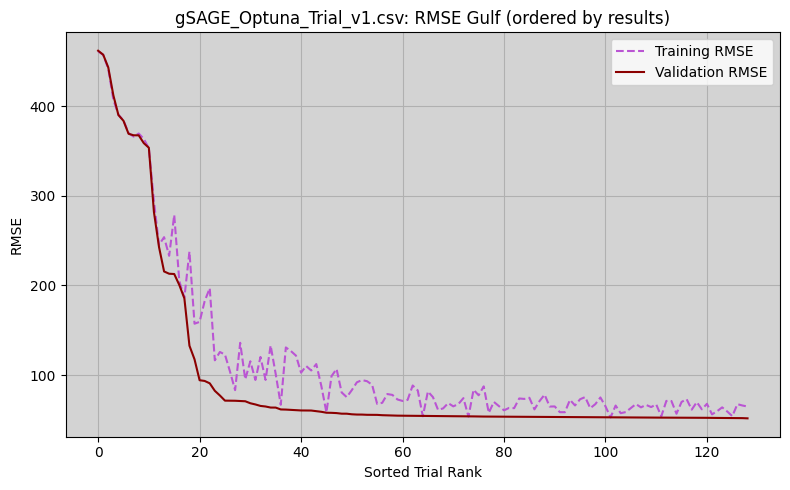

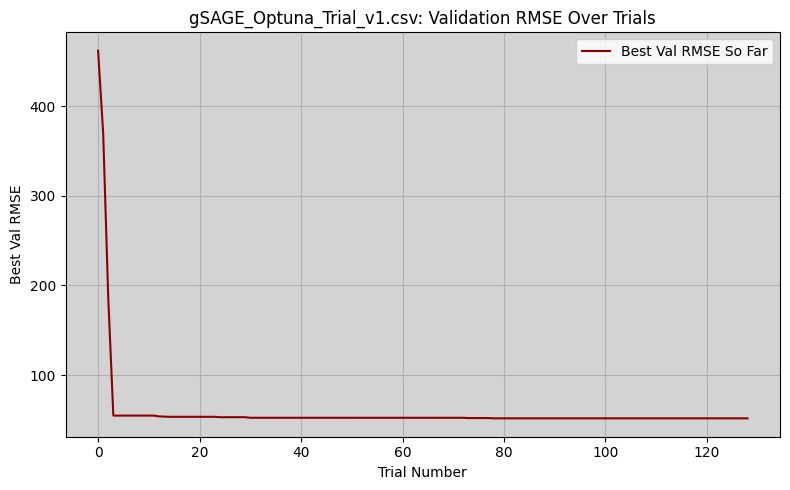

In [ ]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 8.4: VISUALISE THE INTERESTING                               <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> TRACK THE VALIDATION - TRAINING RMSE GULF                              <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
sorted_df = optuna_log_df.sort_values(by='validation_RMSE', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor('lightgrey')
ax.plot(sorted_df.index, sorted_df['training_RMSE'], label='Training RMSE', linestyle='--', color='#BA55D3')
ax.plot(sorted_df.index, sorted_df['validation_RMSE'], label='Validation RMSE', color='#8B0000')
ax.set_xlabel("Sorted Trial Rank")
ax.set_ylabel("RMSE")
ax.set_title(optunafilename + ": RMSE Gulf (ordered by results)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("xTrial_1_" + optunafilename + "_GULF.png", dpi=500, facecolor=fig.get_facecolor())
time.sleep(3)
plt.show()

# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> TRACK THE BEST RMSE SEEN OVER THE TRIALS                               <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
optuna_log_df = pd.DataFrame(optuna_log).sort_values(by='TRIAL') # Ensure it's in trial order

best_so_far = []
current_best = float('inf')
for validation_rmse in optuna_log_df['validation_RMSE']:
    current_best = min(current_best, validation_rmse)
    best_so_far.append(current_best)

# Plot RMSE over trial number
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.set_facecolor('lightgrey')

plt.plot(optuna_log_df['TRIAL'], best_so_far, color='darkred', label='Best Val RMSE So Far')
plt.xlabel("Trial Number")
plt.ylabel("Best Val RMSE")
plt.title(optunafilename + ": Validation RMSE Over Trials")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("xTrial_1_" + optunafilename + "_RMSEprogression.png", dpi=500, facecolor=fig.get_facecolor())
time.sleep(3)
plt.show()

In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 999: Scratch                                                 <<<
# ────────────────────────────────────────────────────────────────────────── <<<